In [1]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt
from sklearn import set_config
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, PowerTransformer, StandardScaler 
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pickle

# Loading the Dataset

In [2]:
df = pd.read_csv("datasets/car_details.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


# Analyze the Dataset

In [3]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['selling_price']), 
                                                    df['selling_price'],
                                                    test_size=0.2,
                                                    random_state=0)
X_train.shape, X_test.shape

((6502, 12), (1626, 12))

# Cleaning the dataset

In [23]:
def extract_name(df):
    df = df.copy()
    df['brand'] = df['name'].str.split().str[0]
    df['car_model'] = df['name'].str.split().str[1]
    df.drop(columns=['name'], inplace=True)
    return df

name_transformer = FunctionTransformer(extract_name)

In [26]:
def extract_car_age(df):
    df = df.copy()
    df['car_age'] = dt.now().year - df['year']
    df.drop(columns=['year'], inplace=True)
    return df

year_transformer = FunctionTransformer(extract_car_age)

In [9]:
def extract_mileage(df):
    df = df.copy()
    df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)').astype(np.float64)
    return df

mileage_transformer = FunctionTransformer(extract_mileage)

In [10]:
def extract_engine (df):
    df = df.copy()
    df['engine'] = df['engine'].str.extract(r'(\d+\.?\d*)').astype(np.float64)
    return df

engine_transformer = FunctionTransformer(extract_engine)

In [11]:
def extract_max_power(df):
    df = df.copy()
    df['max_power'] = df['max_power'].str.extract(r'(\d+\.?\d*)').astype(np.float64)
    return df

max_power_transformer = FunctionTransformer(extract_max_power)

In [12]:
def clean_torque(df):
    df = df.copy()

    def extract_torque(val):
        if pd.isna(val):
            return np.nan
        val = str(val).replace(',', '') 
        match = re.search(r'(\d+\.?\d*)\s*(Nm|kgm)', val, re.IGNORECASE)
        if not match:
            return np.nan
        number, unit = float(match.group(1)), match.group(2).lower()
        if unit == 'kgm':
            number = number * 9.8
        return number

    df['torque'] = df['torque'].apply(extract_torque)
    return df

torque_transformer = FunctionTransformer(clean_torque)

In [27]:
cleaning_pipe = Pipeline(steps = [
    ('name', name_transformer),
    ('year', year_transformer),
    ('mileage', mileage_transformer),
    ('engine', engine_transformer),
    ('max_power', max_power_transformer),
    ('torque', torque_transformer)
])

# Check if every transformer works

In [28]:
temp = name_transformer.fit_transform(df)
print("Name OK")

temp = year_transformer.fit_transform(temp)
print("Year OK")

temp = mileage_transformer.fit_transform(temp)
print("Mileage OK")

temp = engine_transformer.fit_transform(temp)
print("Engine OK")

temp = max_power_transformer.fit_transform(temp)
print("Max Power OK")

temp = torque_transformer.fit_transform(temp)
print("Torque OK")

Name OK
Year OK
Mileage OK
Engine OK
Max Power OK
Torque OK


In [29]:
df_clean = cleaning_pipe.fit_transform(df)
df_clean.skew(numeric_only=True)

selling_price     4.193533
km_driven        11.170910
mileage          -0.142667
engine            1.135269
max_power         1.621261
torque            1.290813
seats             1.969914
car_age           1.072293
dtype: float64

In [30]:
df_clean.isnull().mean() * 100

selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.657480
torque           7.714075
seats            2.718996
brand            0.000000
car_model        0.000000
car_age          0.000000
dtype: float64

In [33]:
for col in df_clean.columns:
    print(col, "->", df_clean[col].dtype, "| unique values:", df_clean[col].nunique())

selling_price -> int64 | unique values: 677
km_driven -> int64 | unique values: 921
fuel -> str | unique values: 4
seller_type -> str | unique values: 3
transmission -> str | unique values: 2
owner -> str | unique values: 5
mileage -> float64 | unique values: 381
engine -> float64 | unique values: 121
max_power -> float64 | unique values: 319
torque -> float64 | unique values: 200
seats -> float64 | unique values: 9
brand -> object | unique values: 32
car_model -> object | unique values: 207
car_age -> int64 | unique values: 29


In [34]:
for col in df_clean.select_dtypes(include='object').columns:
    print(df_clean.groupby(col)['selling_price'].median().sort_values())

C:\Users\Keval\AppData\Local\Temp\ipykernel_17596\1135530791.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:


fuel
LPG       195500.0
CNG       320000.0
Petrol    345000.0
Diesel    550000.0
Name: selling_price, dtype: float64
seller_type
Individual          400000.0
Trustmark Dealer    650000.0
Dealer              690000.0
Name: selling_price, dtype: float64
transmission
Manual        400000.0
Automatic    1100000.0
Name: selling_price, dtype: float64
owner
Fourth & Above Owner     170000.0
Third Owner              225000.0
Second Owner             310000.0
First Owner              550000.0
Test Drive Car          5923000.0
Name: selling_price, dtype: float64
brand
Peugeot            57000.0
Opel               68000.0
Daewoo             86000.0
Ambassador        110500.0
Chevrolet         223000.0
Tata              280000.0
Fiat              280000.0
Ashok             300000.0
Datsun            300000.0
Maruti            366000.0
Nissan            375000.0
Renault           397000.0
Volkswagen        427500.0
Hyundai           434999.0
Ford              480000.0
Mahindra          560000.0
Hon

<Axes: >

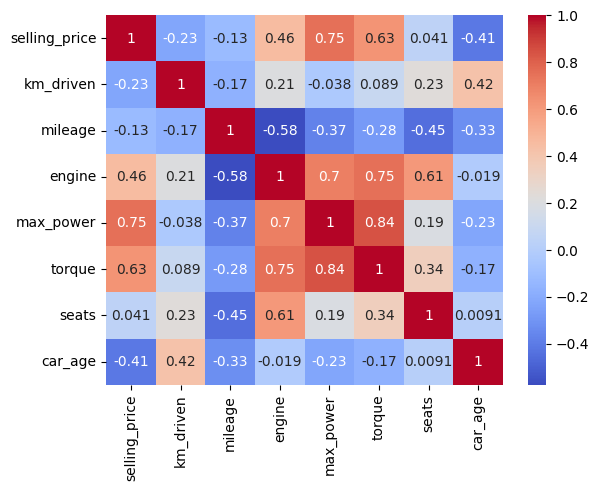

In [50]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [39]:
iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=0), max_iter=100, random_state= 0) 

categorial_imputer_pipe = Pipeline(steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
])

One_Hot_pipe = Pipeline(steps = [
    ('OHE', OneHotEncoder(handle_unknown='ignore',sparse_output=False, dtype = np.int64, drop='first'))
])



owner_pipe = Pipeline(steps=[
    ('encoding', OrdinalEncoder(categories=[['Fourth & Above Owner', 
                                             'Third Owner', 
                                             'Second Owner', 
                                             'First Owner',
                                             'Test Drive Car']], dtype = np.int64))
])

car_model_pipe = Pipeline(steps = [
    ('encode', OneHotEncoder(min_frequency=50, handle_unknown='infrequent_if_exist', dtype = int, sparse_output=False, drop='first'))
])

brand_pipe = Pipeline(steps=[
    ('encode', OneHotEncoder(min_frequency=30, sparse_output=False, handle_unknown='infrequent_if_exist', dtype=int))
])

positive_skewness_pipe = Pipeline(steps=[
    ('log', FunctionTransformer(func=np.log1p)),
    ('scale', StandardScaler())
])

negative_skewness_pipe = Pipeline(steps = [
    ('square', FunctionTransformer(func=np.square)),
    ('scale', StandardScaler())
])

heavy_positive_skewness_pipe = Pipeline(steps = [
    ('yeo-johnson', PowerTransformer(method='yeo-johnson'))
])

scaler_pipe = Pipeline(steps = [
    ('scale', StandardScaler())
])

imputer = ColumnTransformer(transformers=[
    ('categorial_imputer', categorial_imputer_pipe, ['seats']),
    ('iterative_imputer', iterative_imputer, ['mileage', 'car_age', 'torque', 'max_power', 'engine'])
], remainder='passthrough', verbose_feature_names_out=False)

In [41]:
transform = ColumnTransformer(transformers = [
    ('owner', owner_pipe, ['owner']),
    ('ohe', One_Hot_pipe, ['fuel', 'seller_type', 'transmission']),
    ('car_model', car_model_pipe, ['car_model']),
    ('brand', brand_pipe, ['brand']),
    ('positive_skewness', positive_skewness_pipe, ['engine', 'torque', 'car_age']),
    ('heavy_positive', heavy_positive_skewness_pipe, ['km_driven']),
    ('negative_skewness', negative_skewness_pipe, ['max_power']),
    ('scale', scaler_pipe, ['mileage'])
], remainder='passthrough')

In [42]:
def to_dataframe(arr):
    dataframe = pd.DataFrame(arr, columns= imputer.get_feature_names_out())
    dataframe = dataframe.infer_objects()
    return dataframe

In [44]:
preprocessor = Pipeline(steps=[
    ('clean', cleaning_pipe),
    ('imputer', imputer),
    ('dataframe', FunctionTransformer(func= to_dataframe)),
    ('transform', transform)
])

In [45]:
df_imputed = preprocessor.named_steps['imputer'].fit_transform(df_clean)

type(df_imputed), df_imputed.shape

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


(numpy.ndarray, (8128, 14))

In [46]:
dtfm = preprocessor.named_steps['dataframe'].fit_transform(df_imputed)

dtfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   seats          8128 non-null   float64
 1   mileage        8128 non-null   float64
 2   car_age        8128 non-null   float64
 3   torque         8128 non-null   float64
 4   max_power      8128 non-null   float64
 5   engine         8128 non-null   float64
 6   selling_price  8128 non-null   int64  
 7   km_driven      8128 non-null   int64  
 8   fuel           8128 non-null   str    
 9   seller_type    8128 non-null   str    
 10  transmission   8128 non-null   str    
 11  owner          8128 non-null   str    
 12  brand          8128 non-null   str    
 13  car_model      8128 non-null   str    
dtypes: float64(6), int64(2), str(6)
memory usage: 1.2 MB


In [47]:
preprocessor.named_steps['transform'].fit(dtfm)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('owner', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [48]:
final_pipe = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=0))
])

In [49]:
final_pipe.fit(X_train, y_train)

pred = final_pipe.predict(X_test)

r2_score(y_test, pred)

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


0.9453539472164993

In [48]:
cross_val_score(final_pipe, X=df.drop(columns = ['selling_price'], axis = 1), y = df['selling_price'], cv=5, scoring='r2')

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
C:\Users\Keval\AppData\Loca

array([0.96438731, 0.97209199, 0.97707906, 0.95528155, 0.96746831])

Encode - fuel, seller_type, transmission, owner, brand, car_model

scale - selling_price, km_driven, mileange, engine, max_power


In [51]:
pickle.dump(final_pipe, open('models/Car_price_prediction.pkl', 'wb'))

In [52]:
model = pickle.load(open('models/Car_price_prediction.pkl', 'rb'))